In [2]:
!pip install roboflow
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.0/83.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.7/914.7 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.5 MB/s eta 0:0

##**Download Dataset**

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="8sfluO7vEnYWGi015BDt")
project = rf.workspace("gepetito").project("apples-red-green-3b4vs")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Apples-red-&-green-1 in yolov11:: 100%|██████████| 2302/2302 [00:00<00:00, 4509.13it/s]


##**Check GPU Status**

In [ ]:
!nvidia-smi

Tue Feb 11 02:17:48 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

##**Train**

In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo11n.pt")  # load a pretrained model (recommended for training)

# Train the model
results = model.train(data="/content/Apples-red-&-green-1/data.yaml",batch=16, epochs=100, imgsz=640, device='cuda')

Ultralytics 8.3.74 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/Apples-red-&-green-1/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=Tr

train: Scanning /content/Apples-red-&-green-1/train/labels.cache... 1000 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1000/1000 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /content/Apples-red-&-green-1/valid/labels.cache... 97 images, 0 backgrounds, 0 corrupt: 100%|██████████| 97/97 [00:00<?, ?it/s]


Plotting labels to runs/detect/train/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.00125, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to runs/detect/train
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

    100/100      4.77G       0.35     0.2086     0.8715         23        640: 100%|██████████| 63/63 [00:18<00:00,  3.39it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:00<00:00,  4.44it/s]

                   all         97        220      0.933      0.949      0.961      0.909



100 epochs completed in 0.576 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 5.5MB
Optimizer stripped from runs/detect/train/weights/best.pt, 5.5MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.74 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:01<00:00,  2.05it/s]


                   all         97        220      0.959      0.957      0.964      0.911
      good green apple         29         84      0.988      0.988      0.989      0.901
        good red apple         34         77      0.987      0.985       0.99       0.97
    rotten green apple         22         29      0.933      0.954      0.951      0.935
      rotten red apple         21         30      0.927        0.9      0.924      0.838
Speed: 0.2ms preprocess, 3.3ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to runs/detect/train


##**Validation**

In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO("/content/runs/detect/train/weights/best.pt")

# Customize validation settings
validation_results = model.val(data="/content/Apples-red-&-green-1/data.yaml", imgsz=640, batch=16, conf=0.25, iou=0.6, device="cuda")

Ultralytics 8.3.74 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 238 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning /content/Apples-red-&-green-1/valid/labels.cache... 97 images, 0 backgrounds, 0 corrupt: 100%|██████████| 97/97 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.58it/s]


                   all         97        220      0.958      0.957      0.965      0.922
      good green apple         29         84      0.988      0.988      0.993      0.916
        good red apple         34         77      0.987      0.987       0.99      0.976
    rotten green apple         22         29      0.933      0.954      0.961      0.948
      rotten red apple         21         30      0.926        0.9      0.915      0.847
Speed: 2.9ms preprocess, 7.6ms inference, 0.1ms loss, 1.4ms postprocess per image
Results saved to runs/detect/val


##**Set-up**

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import cv2

In [4]:
def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))

In [5]:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'

    !mkdir images
    !wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/truck.jpg
    !wget -P images https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/groceries.jpg

    !wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

PyTorch version: 2.5.1+cu124
Torchvision version: 0.20.1+cu124
CUDA is available: True
  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-go8p5rnn
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-go8p5rnn
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36592 sha256=7b6e2e07853c22569ed2dc56640d780d30bc3954eee1055b5821a2120bab5732
  Stored in directory: /tmp/pip-ephem-wheel-cache-hhym1vjy/wheels/15/d7/bd/05f5f23b7dcbe70cbc6783b06f12143b0cf1a5da5c7b52dcc5
Successfully built segment_anything
--2025-02-12 13:24:16--  https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/truck.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.c

In [6]:
import sys
sys.path.append("..")
from segment_anything import sam_model_registry, SamPredictor

sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

device = "cuda"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

predictor = SamPredictor(sam)

/usr/local/lib/python3.11/dist-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


##**Perform Prediction**

Model summary: 243 layers, 93,735,472 parameters, 93,735,472 gradients

image 1/1 /content/apples2.jpeg: 448x640 2 good red apples, 4 rotten red apples, 12.0ms
Speed: 2.0ms preprocess, 12.0ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)


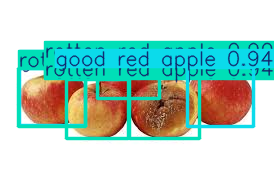

In [8]:
from ultralytics import YOLO
from ultralytics import SAM
import cv2
# import supervision as sv
import numpy as np
import copy
import time
import copy
from google.colab.patches import cv2_imshow

yolo_model = YOLO('/content/apple_detection_best.pt')


# Load a model
segmentation_model = SAM("sam_b.pt")

# Display model information (optional)
segmentation_model.info()

# Run inference with bboxes prompt
# results = model("ultralytics/assets/zidane.jpg", bboxes=[439, 437, 524, 709])


names = {0: 'good green apple', 1: 'good red apple', 2: 'rotten green apple', 3: 'rotten red apple'}


######################## Testing on an Image ##############################

img_path = "/content/apples2.jpeg"
detected_results = yolo_model.predict(img_path)
image = cv2.imread(img_path) ##Generating the image
image_copy = copy.deepcopy(image)

# print(detected_results)

# print(detected_results[0].boxes)

cv2_imshow(detected_results[0].plot())


detected_bounding_boxes = []

for i in range(len(detected_results[0].boxes)):
  class_id = detected_results[0].boxes.cls[i]
  class_id = int(class_id)
  if class_id == 3 and float(detected_results[0].boxes.conf[i]) > 0.9:
    bbox = detected_results[0].boxes.xyxy[i]
    x, y, w, h = bbox
    x, y, w, h = int(x), int(y), int(w), int(h)  # Convert to integers

    detected_bounding_boxes.append([x,y,w,h])

    text = names[class_id]
    cv2.rectangle(image, (x, y), (w, h), (0, 0, 255), 2)
    cv2.putText(image, text, (x-70, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)

    # results = segmentation_model("/content/apples2.jpeg", bboxes=[x, y, w, h])
    # cv2_imshow(results[0].plot())



# cv2.waitKey(0)
# print(image)
# results = plate_detection_model.predict(img_path)
# out = results[0].plot()

# plate = results[0].boxes.xyxy[0]
# x, y, w, h = plate  # Get the bounding box coordinates
# x, y, w, h = int(x), int(y), int(w), int(h)  # Convert to integers

# # Extract the text (if any)
# plate_text = perform_ocr_on_image(image, [x, y, w, h])

#             # Draw the bounding box and the detected text on the frame (optional)
# cv2.rectangle(image, (x, y), (w, h), (0, 255, 0), 2)
# cv2.putText(image, plate_text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

# cv2.imshow('frame', image)
# cv2.waitKey(0)

# print("Detected Plate Text: ", plate_text)

###########################////////////////////////##############################






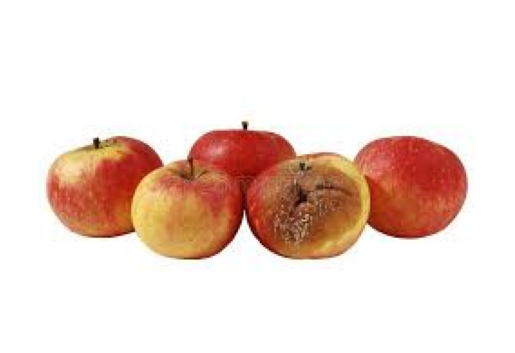

In [26]:
plt.imshow(cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [27]:
predictor.set_image(image_copy)

In [28]:
input_box = np.array(detected_bounding_boxes)
# input_point = np.array([[575, 750]])
# input_label = np.array([0])
print(input_box)

[129  77 199 138]


In [29]:
# masks, _, _ = predictor.predict(
#     point_coords=None,
#     point_labels=None,
#     box=input_box,
#     multimask_output=False,
# )

In [30]:
detected_bounding_boxes = detected_bounding_boxes[0]
print(detected_bounding_boxes[0])

TypeError: 'int' object is not subscriptable

In [31]:
# print(detected_bounding_boxes[0])
masks, scores, logits = predictor.predict(
    box=input_box[None, :],
    multimask_output=False
)

# print(masks, scores, logits)

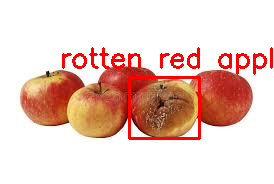

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
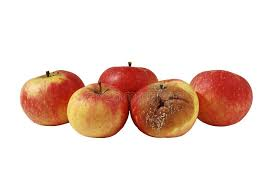

In [46]:
cv2_imshow(image)
cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB)

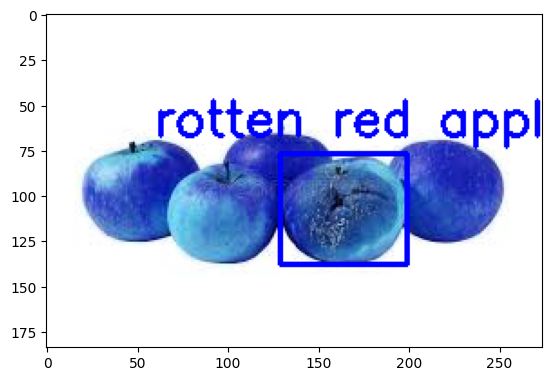

In [33]:
plt.imshow(image)


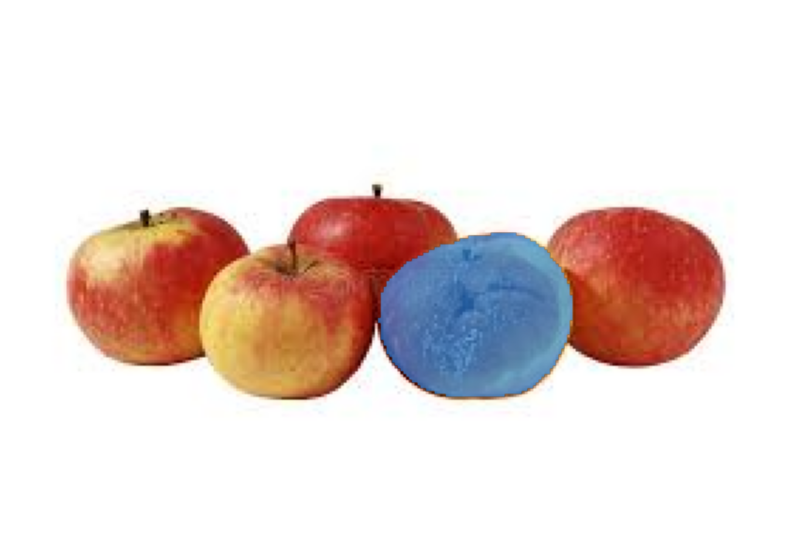

In [45]:
plt.figure(figsize=(10, 10))
# plt.imshow(image)
plt.imshow(cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB))

# for mask in masks:
show_mask(masks, plt.gca())
# show_box(input_box, plt.gca())
# show_points(input_point, input_label, plt.gca())
plt.axis('off')
plt.savefig('/content/segmented_apples.png')
# plt.show()
# cv2_imshow(image)
